## Importing librairies and Reading the dataset

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [28]:
data = pd.read_csv('data/insurance.csv')
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## EDA

In [29]:
# dimension
data.shape

(1338, 7)

In [30]:
# columns (dtypes)
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [31]:
# analyse descriptive 
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [32]:
# missing values?
data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

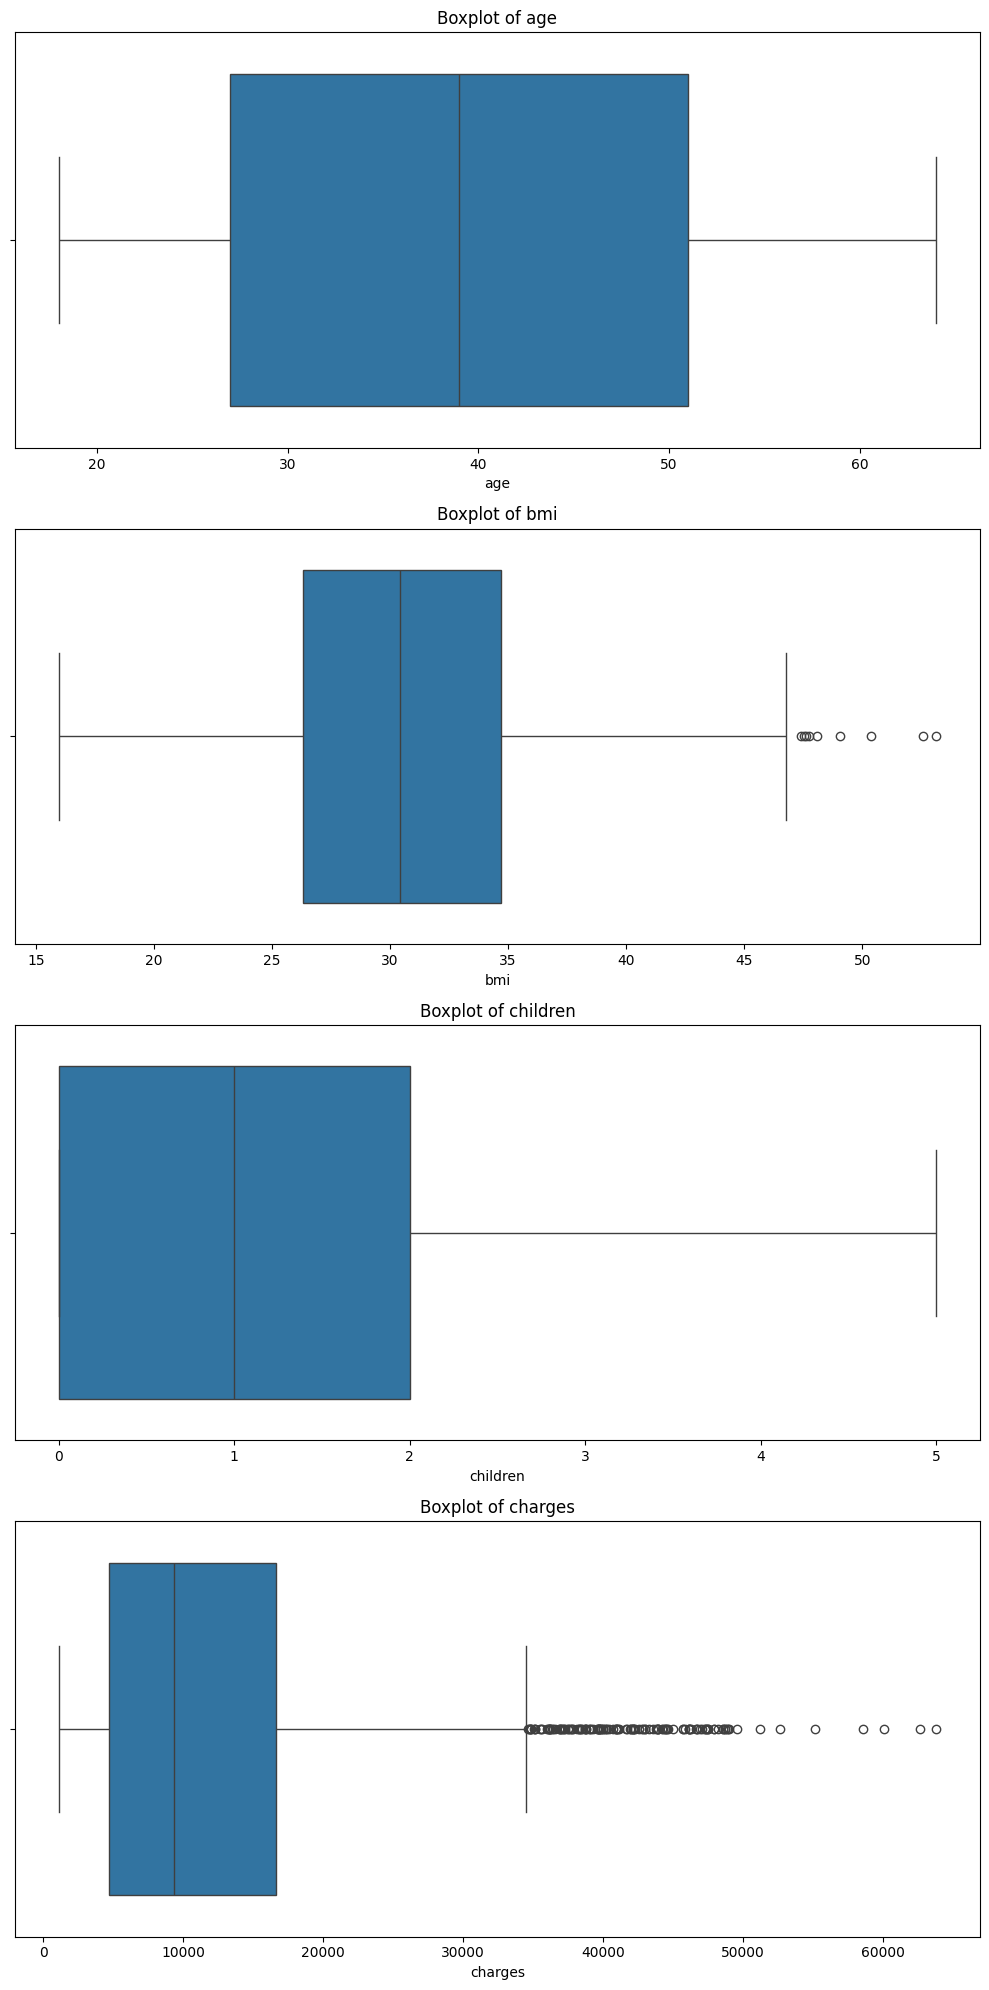

In [33]:
# outliers? (boxplots for numerical columns)
numerical_cols = data.select_dtypes(include=np.number).columns
fig, axes = plt.subplots(len(numerical_cols), 1, figsize=(10, 5*len(numerical_cols)))
for i, col in enumerate(numerical_cols):
    sns.boxplot(x=data[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

In [34]:
# another outlier detection method: IQR 
Q1 = data[numerical_cols].quantile(0.25)
Q3 = data[numerical_cols].quantile(0.75)
IQR = Q3 - Q1
outliers = ((data[numerical_cols] < (Q1 - 1.5 * IQR)) | (data[numerical_cols] > (Q3 + 1.5 * IQR))).sum()
print("Number of outliers in each numerical column:")
print(outliers)

Number of outliers in each numerical column:
age           0
bmi           9
children      0
charges     139
dtype: int64


## Dataset Cleaning

In [35]:
# seuil de 97% for outlier detection (charges)
q97 = data['charges'].quantile(0.97)
outliers_charges = data[data['charges'] > q97]
print(f"Number of outliers in 'charges' column: {len(outliers_charges)}")


Number of outliers in 'charges' column: 41


In [36]:
# delete outliers in 'charges' column
data_clean = data[data['charges'] <= q97].copy()
print(f"Number of rows after removing outliers in 'charges' column: {len(data_clean)}")

Number of rows after removing outliers in 'charges' column: 1297


## Data Preprocessing and Feature Engineering

In [37]:
data_clean.info()

<class 'pandas.DataFrame'>
Index: 1297 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1297 non-null   int64  
 1   sex       1297 non-null   str    
 2   bmi       1297 non-null   float64
 3   children  1297 non-null   int64  
 4   smoker    1297 non-null   str    
 5   region    1297 non-null   str    
 6   charges   1297 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 102.0 KB


In [38]:
# encoding categorical variables
# sex, smoker => label encoding (binary)
# region => one-hot encoding

data_clean['sex'] = data_clean['sex'].map({'male': 0, 'female': 1})
data_clean['smoker'] = data_clean['smoker'].map({'no': 0, 'yes': 1})
data_clean = pd.get_dummies(data_clean, columns=['region'], drop_first=True)

In [39]:
data_clean.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [40]:
# download the cleaned dataset
data_clean.to_csv('data/insurance_clean.csv', index=False)

## Visualisations

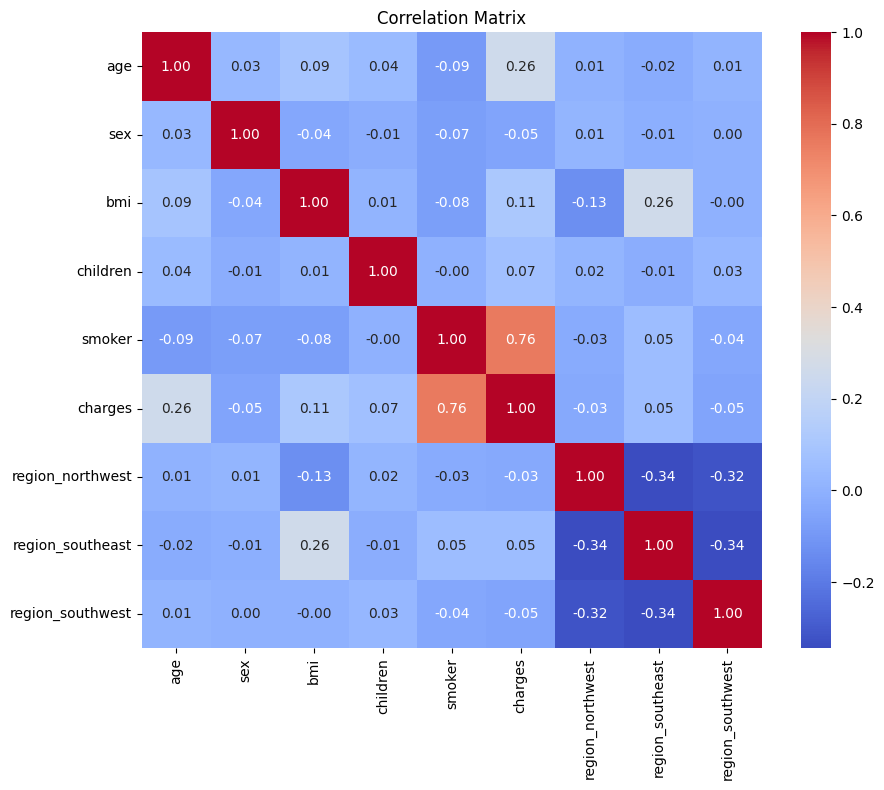

In [41]:
# correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(data_clean.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

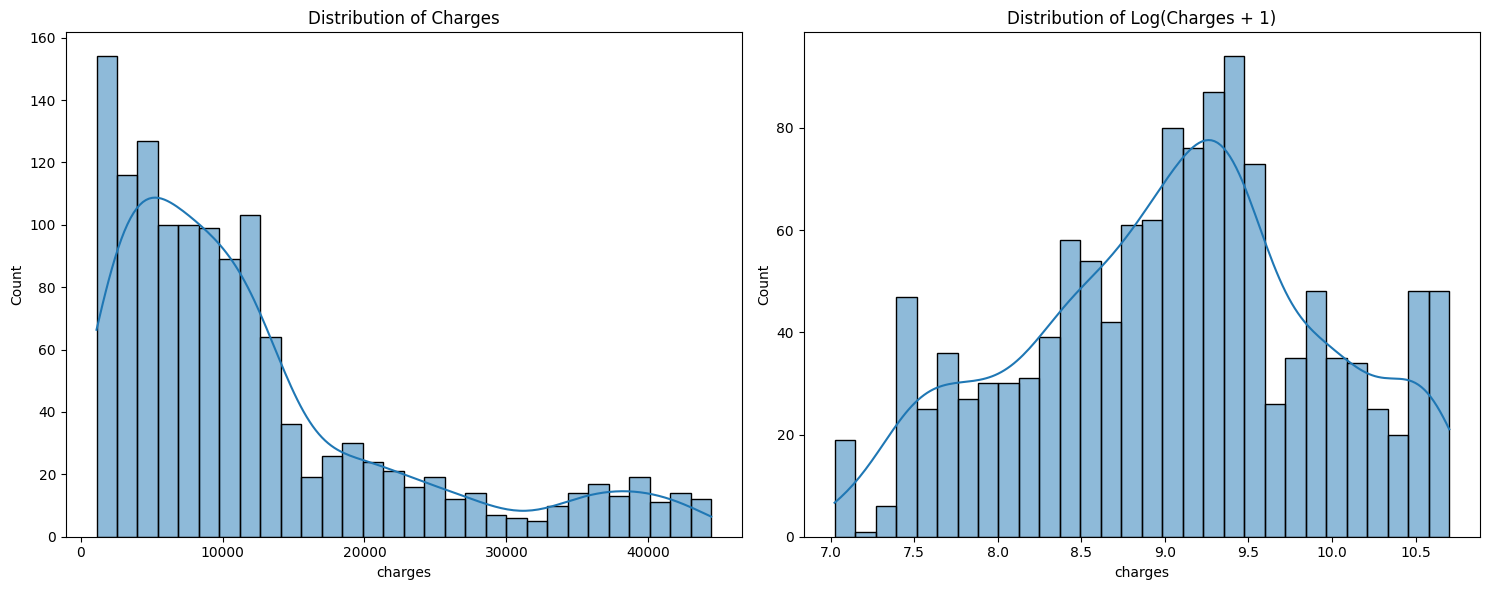

In [42]:
# distribution of the target variable (charges) and its log transformation (subplots)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.histplot(data_clean['charges'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Charges')
sns.histplot(np.log1p(data_clean['charges']), bins=30, kde=True, ax=axes[1])
axes[1].set_title('Distribution of Log(Charges + 1)')
plt.tight_layout()
plt.show()

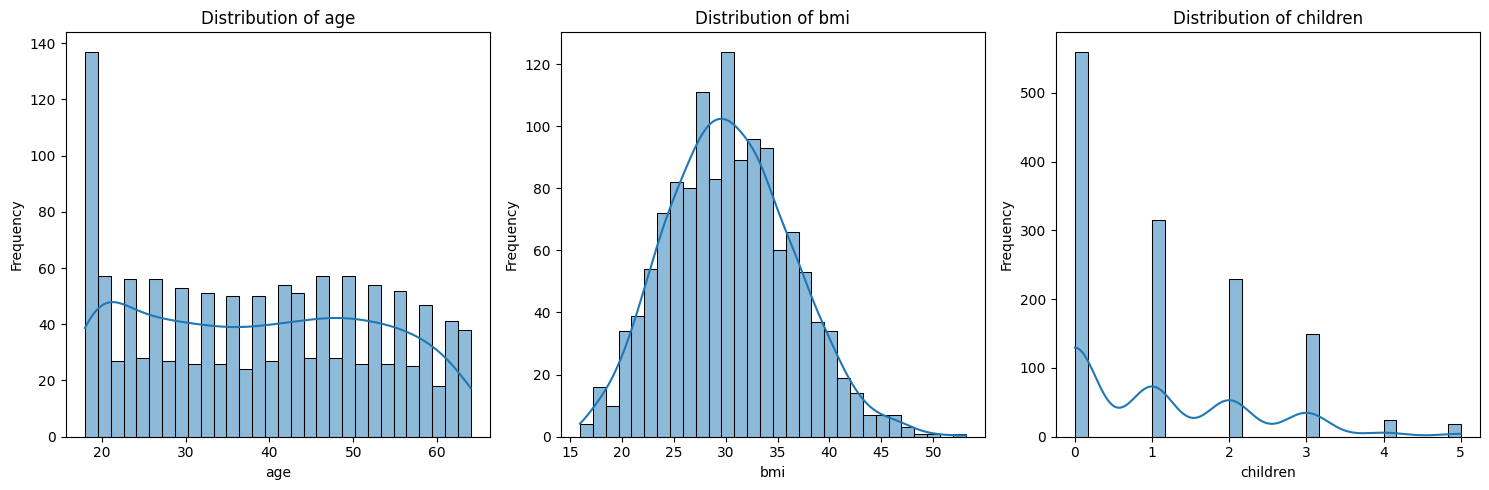

In [43]:
# distribution des autres variables numériques (à part charges) in subplots
var_distr = data_clean[['age', 'bmi', 'children']]

# subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(var_distr.columns):
    sns.histplot(data_clean[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency') 
plt.tight_layout()
plt.show()

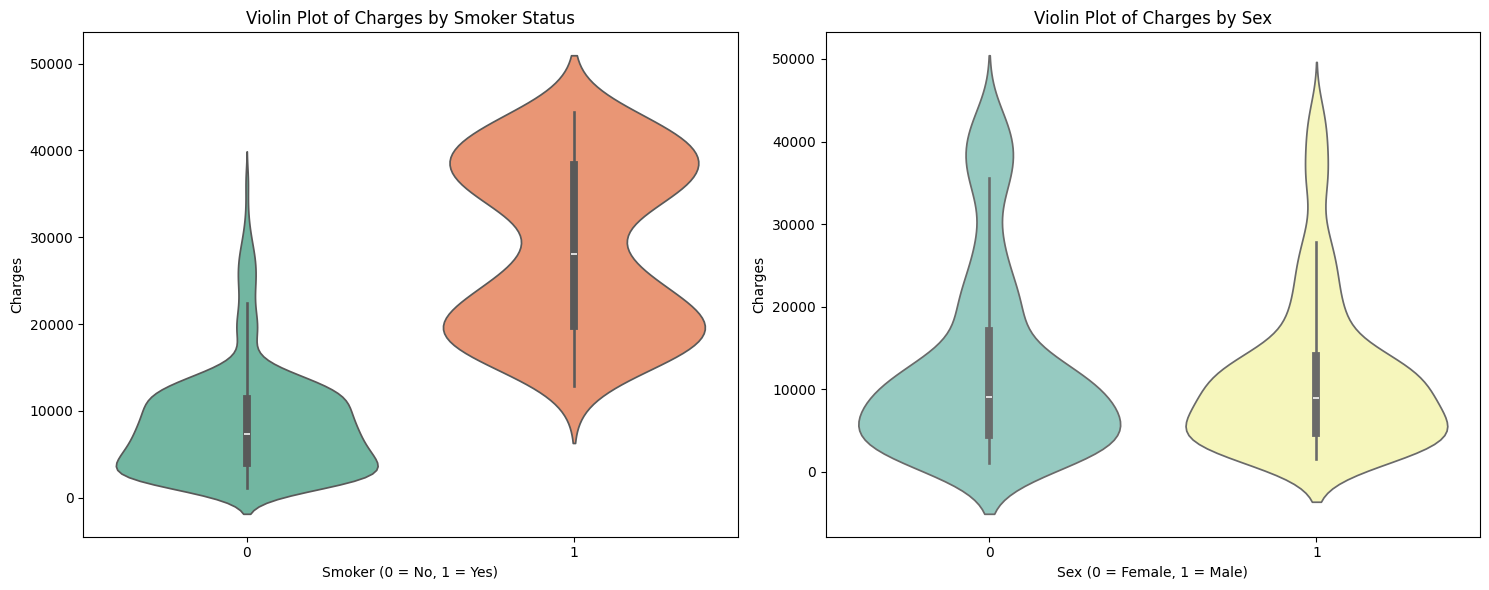

In [44]:
# violin plot (charges vs smoker and charges vs sex)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.violinplot(x='smoker', y='charges', data=data_clean, ax=axes[0], hue='smoker', palette='Set2', legend=False)
axes[0].set_title('Violin Plot of Charges by Smoker Status')
axes[0].set_xlabel('Smoker (0 = No, 1 = Yes)')
axes[0].set_ylabel('Charges')
sns.violinplot(x='sex', y='charges', data=data_clean, ax=axes[1], hue='sex', palette='Set3', legend=False)
axes[1].set_title('Violin Plot of Charges by Sex')
axes[1].set_xlabel('Sex (0 = Female, 1 = Male)')
axes[1].set_ylabel('Charges')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Box plot of charges vs children')

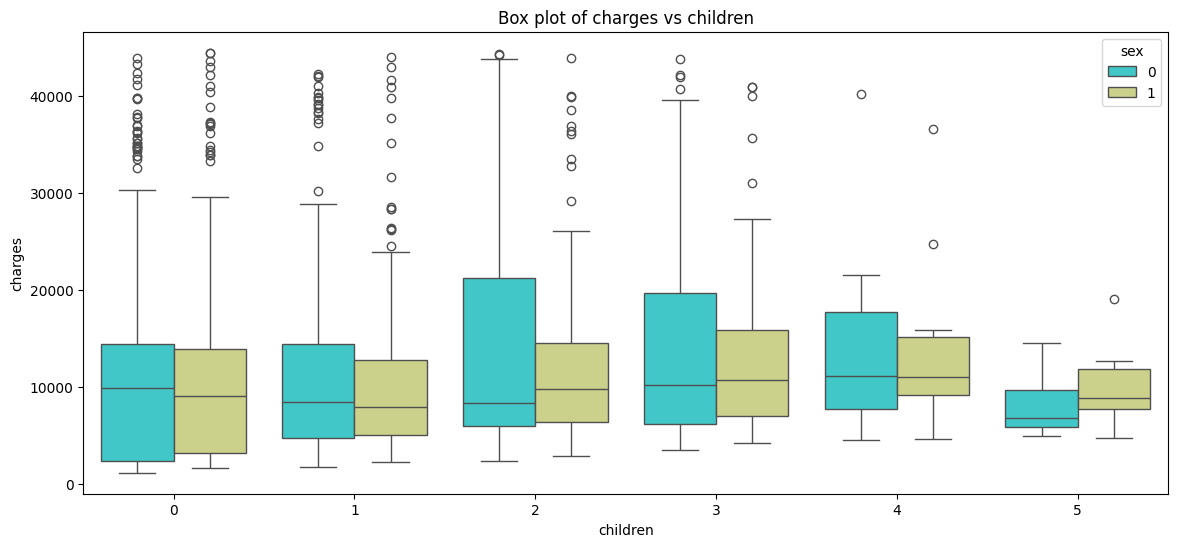

In [45]:
plt.figure(figsize=(14,6))
sns.boxplot(x='children', y='charges',hue='sex',data=data_clean,palette='rainbow')
plt.title('Box plot of charges vs children')

In [46]:
data_clean.groupby('children').agg(['mean','min','max'])['charges']

,mean,min,max
children,,,
0,11414.817299,1121.8739,44423.80300
1,11686.478133,1711.0268,43943.87610
2,13554.623841,2304.0022,44260.74990
3,13801.986914,3443.0640,43753.33705
4,13850.656311,4504.6624,40182.24600
5,8786.035247,4687.7970,19023.26000


## Model Selection

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

def algo_test(x, y):
    algos = {
        'Linear': LinearRegression(),
        'Ridge': Ridge(),
        'Lasso': Lasso(),
        'ElasticNet': ElasticNet(),
        'Random Forest': RandomForestRegressor(random_state=42),
        'Gradient Boosting': GradientBoostingRegressor(random_state=42),
        'KNN': KNeighborsRegressor(),
        'Decision Tree': DecisionTreeRegressor(random_state=42),
        'XGBoost': XGBRegressor(random_state=42),
    }

    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

    # Scale features
    scaler = StandardScaler()
    x_train_scaled = scaler.fit_transform(x_train)
    x_test_scaled = scaler.transform(x_test)

    results = []
    for name, algo in algos.items():
        algo.fit(x_train_scaled, y_train)
        pred = algo.predict(x_test_scaled)
        results.append({
            'Algorithm': name,
            'R_Squared': r2_score(y_test, pred),
            'RMSE': mean_squared_error(y_test, pred) ** 0.5,
            'MAE': mean_absolute_error(y_test, pred),
        })

    result = pd.DataFrame(results).set_index('Algorithm')
    return result.sort_values('R_Squared', ascending=False)

In [48]:
# With log transform
print("=== With Log Transform ===")
X = data_clean.drop('charges', axis=1)
y = np.log1p(data_clean['charges'])
result_log = algo_test(X, y)
display(result_log)

=== With Log Transform ===


,R_Squared,RMSE,MAE
Algorithm,,,
Gradient Boosting,0.804124,0.369626,0.203906
Random Forest,0.778965,0.392647,0.206320
KNN,0.755613,0.412868,0.256411
Linear,0.741219,0.424852,0.256862
Ridge,0.741214,0.424857,0.256960
XGBoost,0.722389,0.440038,0.252613
Decision Tree,0.630935,0.507369,0.245416
ElasticNet,0.052806,0.812815,0.657639
Lasso,-0.002948,0.836395,0.674323


In [49]:
# Without log transform
print("=== Without Log Transform ===")
X = data_clean.drop('charges', axis=1)
y = data_clean['charges']
result_raw = algo_test(X, y)
display(result_raw)

=== Without Log Transform ===


,R_Squared,RMSE,MAE
Algorithm,,,
Gradient Boosting,0.800494,4493.230320,2541.259151
Random Forest,0.773593,4786.588660,2687.235851
XGBoost,0.757443,4954.361014,2988.932333
KNN,0.710085,5416.472707,3386.505345
Ridge,0.683352,5660.691493,3980.114336
Lasso,0.683311,5661.058617,3979.025452
Linear,0.683285,5661.291781,3979.486959
Decision Tree,0.633449,6090.434231,2913.123309
ElasticNet,0.615767,6235.602951,4580.172514


In [50]:
# Side-by-side comparison
comparison = result_raw[['R_Squared']].rename(columns={'R_Squared': 'R² (Raw)'}).join(
    result_log[['R_Squared']].rename(columns={'R_Squared': 'R² (Log)'}),
    how='outer'
)
comparison['Better'] = comparison.apply(lambda row: 'Log' if row['R² (Log)'] > row['R² (Raw)'] else 'Raw', axis=1)
print(comparison.sort_values('R² (Raw)', ascending=False).to_string())

                   R² (Raw)  R² (Log) Better
Algorithm                                   
Gradient Boosting  0.800494  0.804124    Log
Random Forest      0.773593  0.778965    Log
XGBoost            0.757443  0.722389    Raw
KNN                0.710085  0.755613    Log
Ridge              0.683352  0.741214    Log
Lasso              0.683311 -0.002948    Raw
Linear             0.683285  0.741219    Log
Decision Tree      0.633449  0.630935    Raw
ElasticNet         0.615767  0.052806    Raw


## Model Training & Evaluation

In [60]:
# Prepare data (using log transform since it performed better)
X = data_clean.drop('charges', axis=1)
y_log = np.log1p(data_clean['charges'])

x_train, x_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

# Keep raw y_test for evaluation in original scale
_, _, y_train_raw, y_test_raw = train_test_split(X, data_clean['charges'], test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Train Gradient Boosting
gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(x_train_scaled, y_train)
gb_pred_log = gb_model.predict(x_test_scaled)
gb_pred = np.expm1(gb_pred_log)  # convert back to dollars

# Train Random Forest
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(x_train_scaled, y_train)
rf_pred_log = rf_model.predict(x_test_scaled)
rf_pred = np.expm1(rf_pred_log)  # convert back to dollars

print("Models trained successfully!")

Models trained successfully!


In [61]:
# Evaluation metrics (in original dollar scale)
from sklearn.metrics import mean_absolute_percentage_error

models = {'Gradient Boosting': gb_pred, 'Random Forest': rf_pred}

eval_results = []
for name, pred in models.items():
    eval_results.append({
        'Model': name,
        'R²': r2_score(y_test_raw, pred),
        'RMSE': mean_squared_error(y_test_raw, pred) ** 0.5,
        'MAE': mean_absolute_error(y_test_raw, pred),
        'MAPE (%)': mean_absolute_percentage_error(y_test_raw, pred) * 100
    })

eval_df = pd.DataFrame(eval_results).set_index('Model')
display(eval_df)

,R²,RMSE,MAE,MAPE (%)
Model,,,,
Gradient Boosting,0.796518,4537.784558,2221.190431,17.721406
Random Forest,0.789806,4612.015229,2246.559804,18.918776


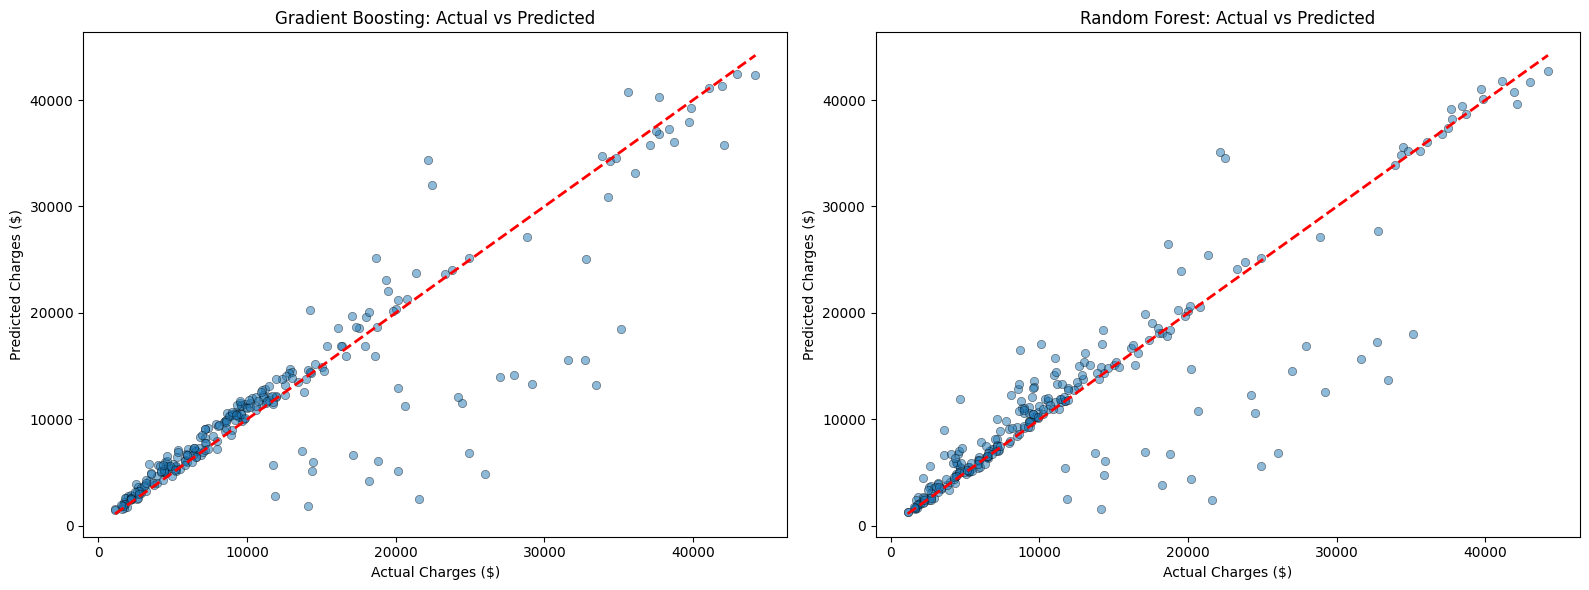

In [53]:
# Actual vs Predicted scatter plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (name, pred) in zip(axes, models.items()):
    ax.scatter(y_test_raw, pred, alpha=0.5, edgecolors='k', linewidth=0.5)
    ax.plot([y_test_raw.min(), y_test_raw.max()], [y_test_raw.min(), y_test_raw.max()], 'r--', lw=2)
    ax.set_title(f'{name}: Actual vs Predicted')
    ax.set_xlabel('Actual Charges ($)')
    ax.set_ylabel('Predicted Charges ($)')

plt.tight_layout()
plt.show()

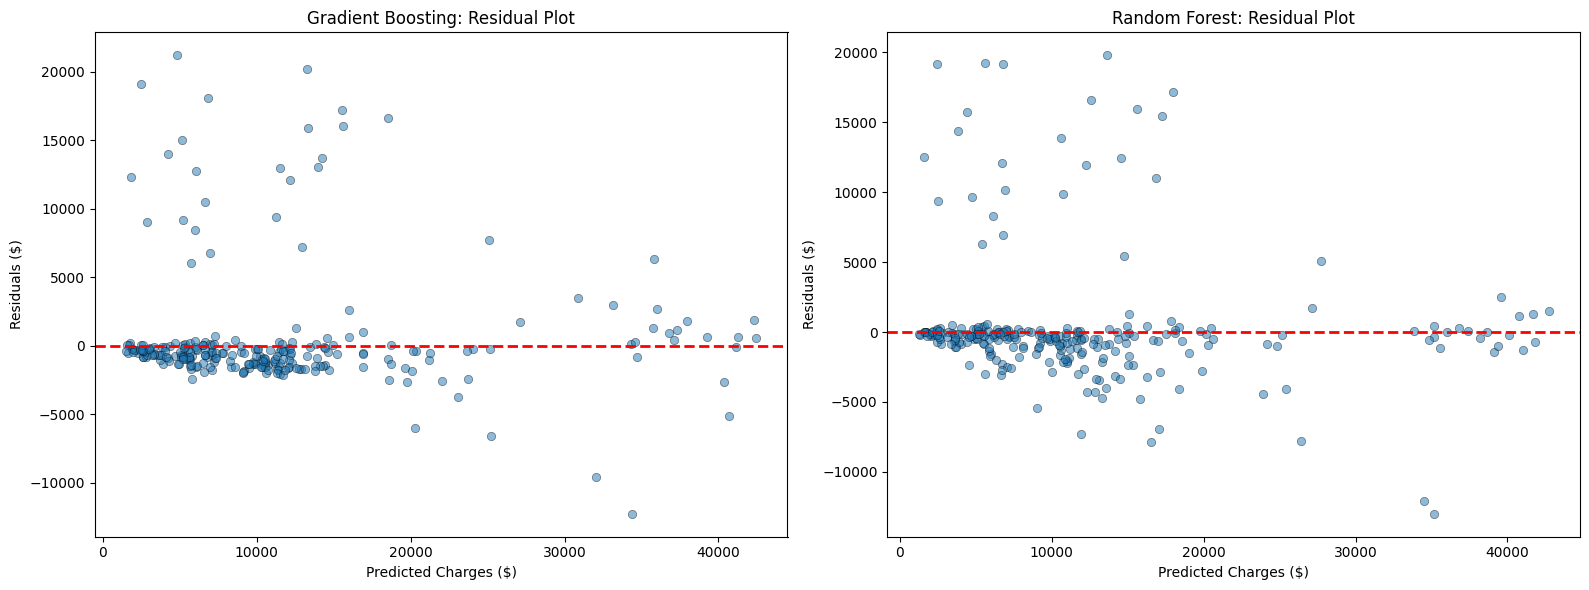

In [54]:
# Residual plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (name, pred) in zip(axes, models.items()):
    residuals = y_test_raw - pred
    ax.scatter(pred, residuals, alpha=0.5, edgecolors='k', linewidth=0.5)
    ax.axhline(y=0, color='r', linestyle='--', lw=2)
    ax.set_title(f'{name}: Residual Plot')
    ax.set_xlabel('Predicted Charges ($)')
    ax.set_ylabel('Residuals ($)')

plt.tight_layout()
plt.show()

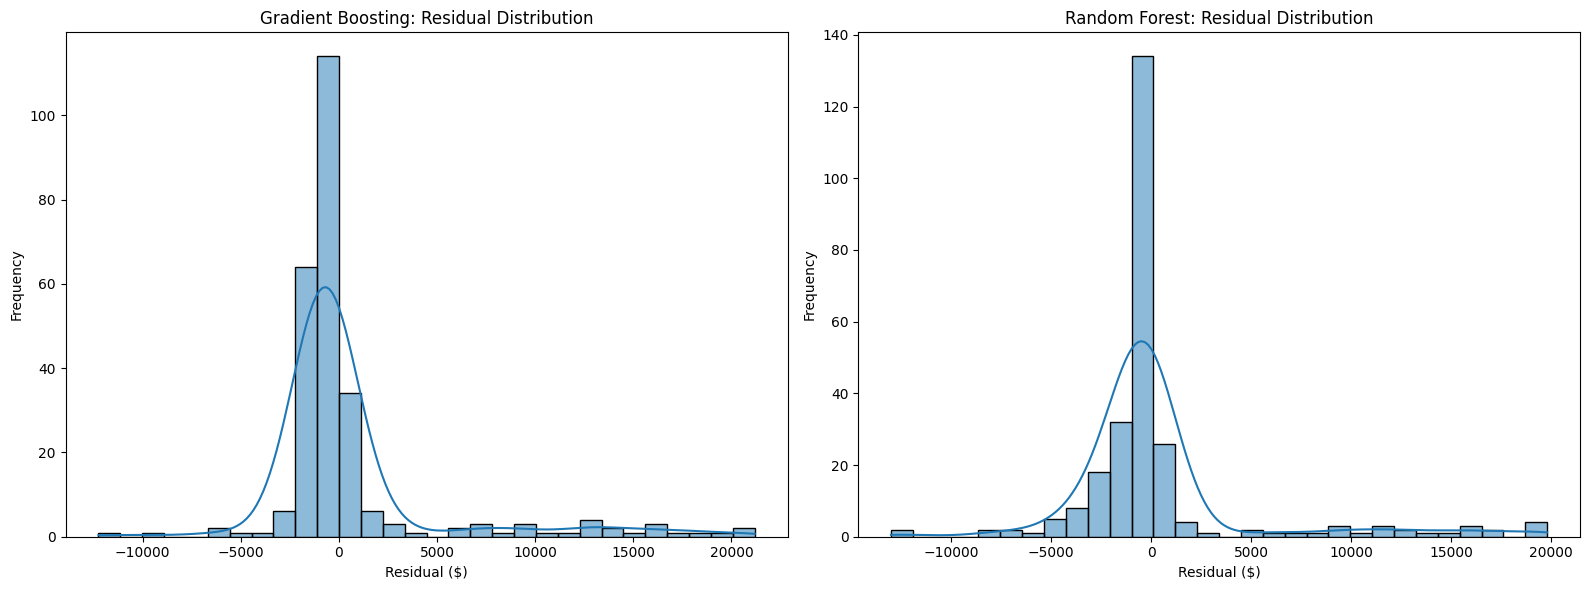

In [55]:
# Residual distribution (histogram)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (name, pred) in zip(axes, models.items()):
    residuals = y_test_raw - pred
    sns.histplot(residuals, bins=30, kde=True, ax=ax)
    ax.set_title(f'{name}: Residual Distribution')
    ax.set_xlabel('Residual ($)')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

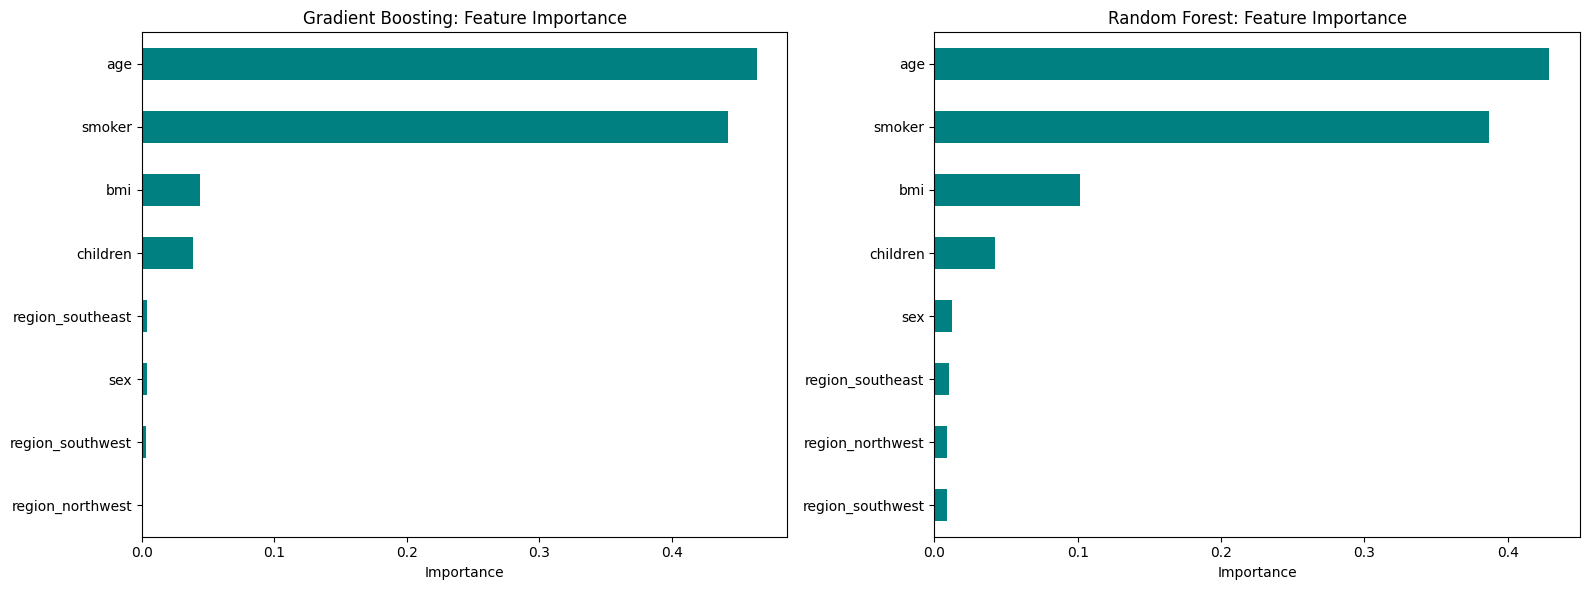

In [58]:
# Feature importance comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (name, model) in zip(axes, [('Gradient Boosting', gb_model), ('Random Forest', rf_model)]):
    importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)
    importances.plot(kind='barh', ax=ax, color='teal')
    ax.set_title(f'{name}: Feature Importance')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

In [63]:
import joblib
import os

os.makedirs('models', exist_ok=True)

# Save models
joblib.dump(gb_model, 'models/gradient_boosting.pkl')
joblib.dump(rf_model, 'models/random_forest.pkl')
joblib.dump(scaler, 'models/scaler.pkl')

print("Saved to models/ folder:")
for f in os.listdir('models'):
    print(f"  - {f}")

Saved to models/ folder:
  - gradient_boosting.pkl
  - random_forest.pkl
  - scaler.pkl
